In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, precision_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.metrics import f1_score, roc_auc_score
from scipy.stats import skew
from scipy.stats import kurtosis

## Dataset loading - ucitavanje dataseta

In [5]:
df=pd.read_csv('../datasets/dataset1.csv')

## Display info about data and first five columns - prikaz informacija o datasetu i prvih 5 kolona iz dataseta

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dob                       1205 non-null   int64  
 1   sistolicki_krvni_tlak     1200 non-null   float64
 2   dijastolicki_krvni_tlak   1201 non-null   float64
 3   glukoza_u_krvi            1203 non-null   float64
 4   tjelesna_temp             1205 non-null   int64  
 5   BMI                       1187 non-null   float64
 6   komplikacije_u_proslosti  1203 non-null   float64
 7   dijabetes                 1203 non-null   float64
 8   gestacijski_dijabetes     1205 non-null   int64  
 9   mentalno_zdravlje         1205 non-null   int64  
 10  otkucaji_srca             1203 non-null   float64
 11  nivo_rizika               1187 non-null   object 
dtypes: float64(7), int64(4), object(1)
memory usage: 113.1+ KB


In [7]:
df.head()

,dob,sistolicki_krvni_tlak,dijastolicki_krvni_tlak,glukoza_u_krvi,tjelesna_temp,BMI,komplikacije_u_proslosti,dijabetes,gestacijski_dijabetes,mentalno_zdravlje,otkucaji_srca,nivo_rizika
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


## Converting Farenheit into Celsius - pretvaranje Farenhajta u stepene Celzijusove skale

In [8]:
df['tjelesna_temp'] = ((df['tjelesna_temp'] - 32) * 5/9).round(2)

In [9]:
df.head()

,dob,sistolicki_krvni_tlak,dijastolicki_krvni_tlak,glukoza_u_krvi,tjelesna_temp,BMI,komplikacije_u_proslosti,dijabetes,gestacijski_dijabetes,mentalno_zdravlje,otkucaji_srca,nivo_rizika
0,22,90.0,60.0,9.0,37.78,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,36.67,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,36.67,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,36.67,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,36.67,19.7,0.0,0.0,0,0,74.0,Low


In [56]:
df['nivo_rizika'].unique()

array(['High', 'Low', nan], dtype=object)

## Displaying the number of missing values related to each variable
## Prikaz broja nedostajućih vrijednosti za svaku varijablu

In [57]:
print(df.isnull().sum()) 

dob                          0
sistolicki_krvni_tlak        5
dijastolicki_krvni_tlak      4
glukoza_u_krvi               2
tjelesna_temp                0
BMI                         18
komplikacije_u_proslosti     2
dijabetes                    2
gestacijski_dijabetes        0
mentalno_zdravlje            0
otkucaji_srca                2
nivo_rizika                 18
dtype: int64


## Calculating skewness for numerical variables
## Računanje asimetrije (skewness) za numeričke varijable

In [58]:
varijable = [
    'sistolicki_krvni_tlak',
    'dijastolicki_krvni_tlak',
    'glukoza_u_krvi',
    'BMI',
    'komplikacije_u_proslosti',
    'dijabetes',
    'otkucaji_srca'
]


skewness_values = {}
for var in varijable:
    if var in df.columns:
       
        podaci = df[var].dropna()
        
        
        if pd.api.types.is_numeric_dtype(podaci):
            skewness_values[var] = skew(podaci)
        else:
            print(f"Varijabla '{var}' nije numerička. Skewness se ne računa.")
            skewness_values[var] = None
    else:
        print(f"Varijabla '{var}' ne postoji u DataFrame-u.")
        skewness_values[var] = None


print("\nKoeficijent iskrivljenosti (skewness):")
for var, sk in skewness_values.items():
    if sk is not None:
        print(f"{var}: {sk:.4f}")
    else:
        print(f"{var}: nije izračunat")


Koeficijent iskrivljenosti (skewness):
sistolicki_krvni_tlak: 0.2571
dijastolicki_krvni_tlak: 0.3772
glukoza_u_krvi: 1.5781
BMI: 0.4574
komplikacije_u_proslosti: 1.7071
dijabetes: 0.9339
otkucaji_srca: 0.2097


## Filling the missing values of numerical variables with mean and median 
## Popunjavanje nedostajućih vrijednosti za numeričke varijable putem mean i median vrijednosti

In [59]:
skewness_dict = {
    'sistolicki_krvni_tlak': 0.2571,
    'dijastolicki_krvni_tlak': 0.3772,
    'glukoza_u_krvi': 1.5781,
    'BMI': 0.4574,
    'komplikacije_u_proslosti': 1.7071,
    'dijabetes': 0.9339,
    'otkucaji_srca': 0.2097
}

for var, skew_val in skewness_dict.items():
    if var not in df.columns:
        print(f"Varijabla '{var}' ne postoji u DataFrame-u.")
        continue
    
    if skew_val < -1 or skew_val > 1:
        fill_value = df[var].median(skipna=True)
        method = "median"
    else:
        fill_value = df[var].mean(skipna=True)
        method = "mean"
    
    df[var] = df[var].fillna(fill_value)
    
    print(f"{var}: skew={skew_val:.4f} → popunjeno sa {method} = {fill_value:.4f}")

print("\nPreostale missing vrijednosti:")
print(df[list(skewness_dict.keys())].isnull().sum())

sistolicki_krvni_tlak: skew=0.2571 → popunjeno sa mean = 116.8192
dijastolicki_krvni_tlak: skew=0.3772 → popunjeno sa mean = 77.1665
glukoza_u_krvi: skew=1.5781 → popunjeno sa median = 6.9000
BMI: skew=0.4574 → popunjeno sa mean = 23.3151
komplikacije_u_proslosti: skew=1.7071 → popunjeno sa median = 0.0000
dijabetes: skew=0.9339 → popunjeno sa mean = 0.2884
otkucaji_srca: skew=0.2097 → popunjeno sa mean = 75.8171

Preostale missing vrijednosti:
sistolicki_krvni_tlak       0
dijastolicki_krvni_tlak     0
glukoza_u_krvi              0
BMI                         0
komplikacije_u_proslosti    0
dijabetes                   0
otkucaji_srca               0
dtype: int64


## Droping the rows with missing value for "nivo rizika" -> label column
## Brisanje redova u kojima nedostaju vrijednosti za nivo rizika

In [60]:
print(df['nivo_rizika'].value_counts(dropna=False))

nivo_rizika
Low     713
High    474
NaN      18
Name: count, dtype: int64


In [61]:
df = df.dropna(subset=['nivo_rizika'])

## Encoding categorical columns
## Enkodiranje kategoričkih varijabli

In [62]:
encoder = LabelEncoder()

In [63]:
df['nivo_rizika'].unique()

array(['High', 'Low'], dtype=object)

In [64]:
df['nivo_rizika'] = df['nivo_rizika'].map({'High':1, 'Low':0})

In [65]:
df.head()

,dob,sistolicki_krvni_tlak,dijastolicki_krvni_tlak,glukoza_u_krvi,tjelesna_temp,BMI,komplikacije_u_proslosti,dijabetes,gestacijski_dijabetes,mentalno_zdravlje,otkucaji_srca,nivo_rizika
0,22,90.0,60.0,9.0,37.78,18.0,1.0,1.0,0,1,80.0,1
1,22,110.0,70.0,7.1,36.67,20.4,0.0,0.0,0,0,74.0,0
2,27,110.0,70.0,7.5,36.67,23.0,1.0,0.0,0,0,72.0,0
3,20,100.0,70.0,7.2,36.67,21.2,0.0,0.0,0,0,74.0,0
4,20,90.0,60.0,7.5,36.67,19.7,0.0,0.0,0,0,74.0,0


## Descriptive statistic
## Deskriptivna statistika

In [ ]:
df.describe() 

,dob,sistolicki_krvni_tlak,dijastolicki_krvni_tlak,glukoza_u_krvi,tjelesna_temp,BMI,komplikacije_u_proslosti,dijabetes,gestacijski_dijabetes,mentalno_zdravlje,otkucaji_srca,nivo_rizika
count,1187.000000,1187.000000,1187.000000,1187.000000,1187.000000,1187.000000,1187.000000,1187.000000,1187.000000,1187.000000,1187.000000,1187.000000
mean,27.764111,116.841008,77.208368,7.515906,36.889840,23.339521,0.176917,0.290049,0.117944,0.335299,75.843148,0.399326
std,12.645309,18.663392,14.262284,3.051976,0.604018,3.860646,0.381759,0.453785,0.322678,0.472294,7.220616,0.489966
min,10.000000,70.000000,40.000000,3.000000,36.110000,0.000000,0.000000,0.000000,0.000000,0.000000,58.000000,0.000000
25%,21.000000,100.000000,65.000000,6.000000,36.670000,21.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000
50%,25.000000,120.000000,80.000000,6.900000,36.670000,23.000000,0.000000,0.000000,0.000000,0.000000,76.000000,0.000000
75%,32.000000,130.000000,90.000000,7.950000,36.670000,25.000000,0.000000,1.000000,0.000000,1.000000,80.000000,1.000000
max,325.000000,200.000000,140.000000,19.000000,39.440000,37.000000,1.000000,1.000000,1.000000,1.000000,92.000000,1.000000


### Droping the raw with outlier value for "dob" column -> 325
### Brisanje reda gdje je vrijednost za dob 325

In [67]:
indeksi_za_izbacivanje = df[df['dob'] == 325].index

df.drop(indeksi_za_izbacivanje, inplace=True)

In [68]:
print(df['dob'].max())

65


In [69]:
df['dob'].unique()

array([22, 27, 20, 23, 26, 25, 19, 18, 24, 21, 44, 17, 28, 40, 37, 29, 34,
       35, 36, 32, 38, 48, 30, 39, 31, 33, 41, 42, 15, 50, 63, 55, 49, 16,
       12, 60, 65, 43, 13, 54, 10, 45])

In [70]:
print(df[(df['dob'] < 15) | (df['dob'] > 50)].shape[0])

46


### Considering the fact that the range for variable age is between 10 and 65, it is decided to keep data between 15 and 50.
### Uzimajući u obzir da je opseg varijable dob između 10 i 65, odlučeno je da se zadrže samo podaci koji su između 15 i 50 godina starosti

In [71]:
df = df[(df['dob'] >= 15) & (df['dob'] <= 50)]

print(f"Broj redova nakon čišćenja: {len(df)}")

Broj redova nakon čišćenja: 1140


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1140 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dob                       1140 non-null   int64  
 1   sistolicki_krvni_tlak     1140 non-null   float64
 2   dijastolicki_krvni_tlak   1140 non-null   float64
 3   glukoza_u_krvi            1140 non-null   float64
 4   tjelesna_temp             1140 non-null   float64
 5   BMI                       1140 non-null   float64
 6   komplikacije_u_proslosti  1140 non-null   float64
 7   dijabetes                 1140 non-null   float64
 8   gestacijski_dijabetes     1140 non-null   int64  
 9   mentalno_zdravlje         1140 non-null   int64  
 10  otkucaji_srca             1140 non-null   float64
 11  nivo_rizika               1140 non-null   int64  
dtypes: float64(8), int64(4)
memory usage: 115.8 KB


## Calculating the kurtosis value for numerical variables
## Računanje zaobljenosti (kurtosis) za numeričke varijable

In [73]:
varijable = [
    'sistolicki_krvni_tlak',
    'dijastolicki_krvni_tlak',
    'glukoza_u_krvi',
    'BMI',
    'komplikacije_u_proslosti',
    'dijabetes',
    'otkucaji_srca'
]

kurtosis_values = {}
for var in varijable:
    if var in df.columns:
        podaci = df[var].dropna()
        
        if pd.api.types.is_numeric_dtype(podaci):
            kurtosis_values[var] = kurtosis(podaci, fisher=True)
        else:
            print(f"Varijabla '{var}' nije numerička. Kurtosis se ne računa.")
            kurtosis_values[var] = None
    else:
        print(f"Varijabla '{var}' ne postoji u DataFrame-u.")
        kurtosis_values[var] = None

print("\nKoeficijent kurtosisa (Fisher, excess kurtosis):")
print("(0 = normalna distribucija, >0 = oštriji vrh, <0 = plosnatiji vrh)")
for var, kurt in kurtosis_values.items():
    if kurt is not None:
        print(f"{var}: {kurt:.4f}")
    else:
        print(f"{var}: nije izračunat")


Koeficijent kurtosisa (Fisher, excess kurtosis):
(0 = normalna distribucija, >0 = oštriji vrh, <0 = plosnatiji vrh)
sistolicki_krvni_tlak: 0.4394
dijastolicki_krvni_tlak: -0.2885
glukoza_u_krvi: 2.7801
BMI: 1.3348
komplikacije_u_proslosti: 0.7291
dijabetes: -1.1214
otkucaji_srca: -0.1696


## Histograms for numeric variables
## Prikaz histograma za numeričke varijable

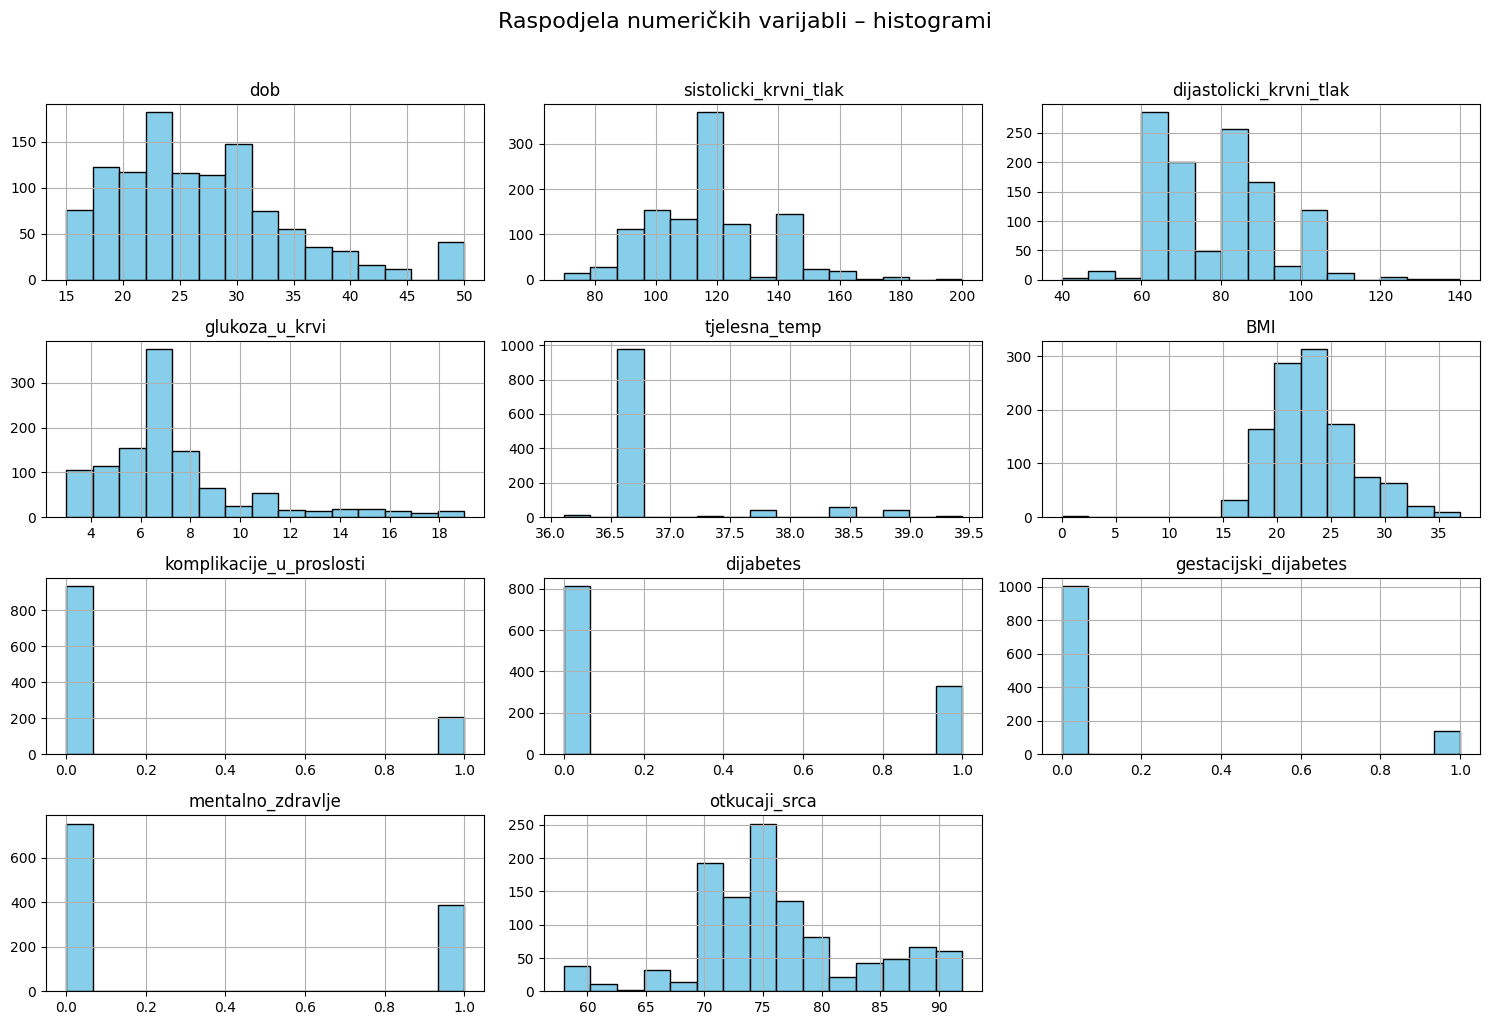

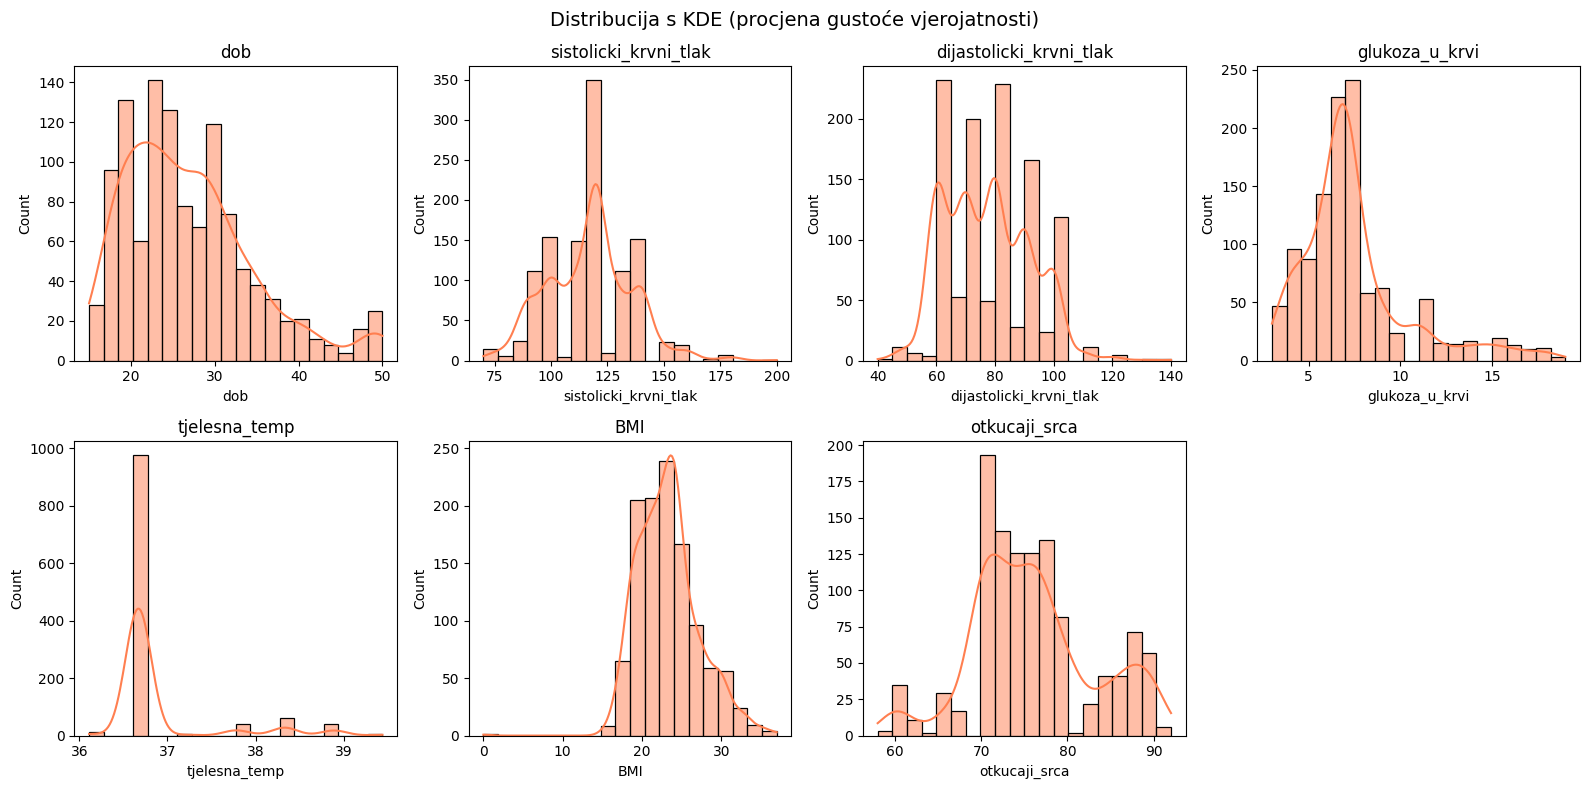

In [74]:
numericke_za_graf = [
    'dob',
    'sistolicki_krvni_tlak',
    'dijastolicki_krvni_tlak',
    'glukoza_u_krvi',
    'tjelesna_temp',
    'BMI',
    'komplikacije_u_proslosti',
    'dijabetes',
    'gestacijski_dijabetes',
    'mentalno_zdravlje',
    'otkucaji_srca'
]

postojece = [var for var in numericke_za_graf if var in df.columns]
if len(postojece) != len(numericke_za_graf):
    print("Upozorenje: sljedeće varijable ne postoje u DataFrame-u:")
    print(set(numericke_za_graf) - set(postojece))

df[postojece].hist(bins=15, figsize=(15, 10), layout=(4, 3), 
                   color='skyblue', edgecolor='black')
plt.suptitle('Raspodjela numeričkih varijabli – histogrami', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# --- Density plot (KDE) ---
kontinuirane = ['dob', 'sistolicki_krvni_tlak', 'dijastolicki_krvni_tlak', 
                'glukoza_u_krvi', 'tjelesna_temp', 'BMI', 
                'otkucaji_srca']
kontinuirane = [var for var in kontinuirane if var in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, var in enumerate(kontinuirane):
    sns.histplot(df[var], kde=True, bins=20, ax=axes[i], color='coral')
    axes[i].set_title(var)
    
for j in range(len(kontinuirane), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribucija s KDE (procjena gustoće vjerojatnosti)', fontsize=14)
plt.tight_layout()
plt.show()

## Pie chart for categorical variable - "level of risk"
## Prikaz "pie chart-a" za kategoričku varijablu -> nivo_rizika

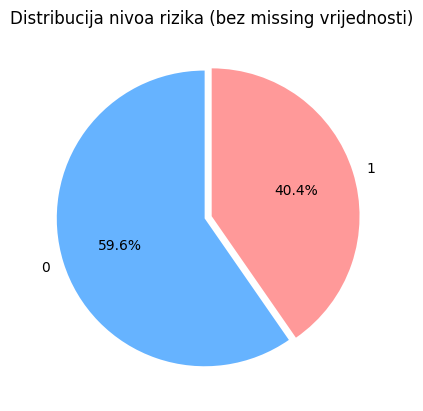

In [75]:
podaci = df['nivo_rizika'].dropna()
podaci.value_counts().plot(kind='pie', autopct='%1.1f%%', 
                           colors=['#66b3ff','#ff9999',], 
                           startangle=90, explode=(0.05, 0))
plt.title('Distribucija nivoa rizika (bez missing vrijednosti)')
plt.ylabel('')  
plt.show()

## Correlation matrix
## Korelacijska matrica

In [76]:
correlation_matrix = df.corr(method='pearson')
print(correlation_matrix)

                               dob  sistolicki_krvni_tlak  \
dob                       1.000000               0.272058   
sistolicki_krvni_tlak     0.272058               1.000000   
dijastolicki_krvni_tlak   0.247684               0.789834   
glukoza_u_krvi            0.631303               0.325386   
tjelesna_temp            -0.092631              -0.174061   
BMI                       0.351126               0.278045   
komplikacije_u_proslosti  0.268233               0.130432   
dijabetes                 0.268564               0.145549   
gestacijski_dijabetes    -0.048826               0.130213   
mentalno_zdravlje         0.142593               0.181586   
otkucaji_srca             0.161900               0.147213   
nivo_rizika               0.215524               0.272855   

                          dijastolicki_krvni_tlak  glukoza_u_krvi  \
dob                                      0.247684        0.631303   
sistolicki_krvni_tlak                    0.789834        0.325386   

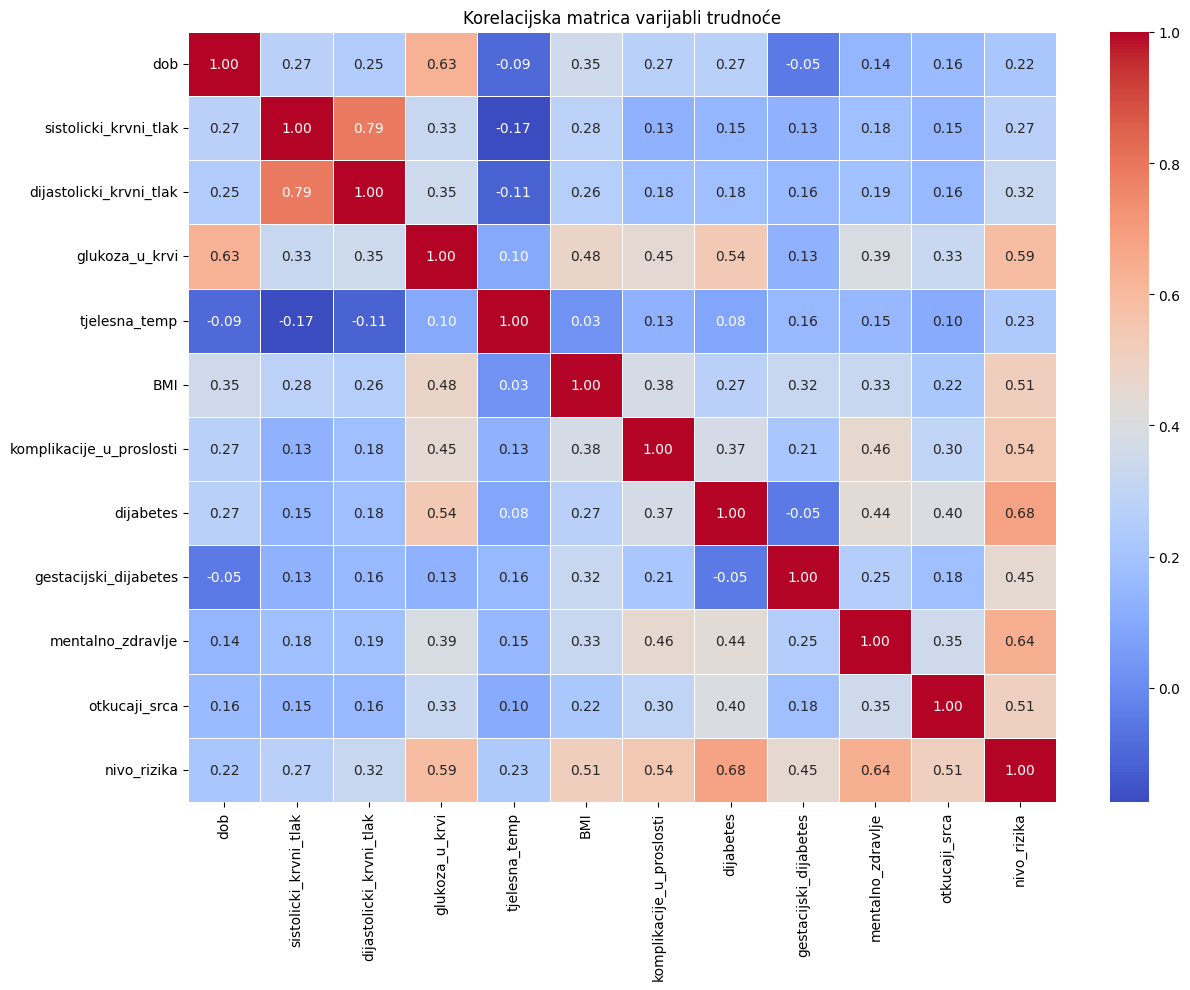

In [77]:
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Korelacijska matrica varijabli trudnoće')
plt.show()

## Train and test split
## Dijeljenje dataseta na trening i test set

In [78]:
x = df.drop(columns=['nivo_rizika'])
y = df['nivo_rizika']

In [79]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1140 entries, 0 to 1204
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dob                       1140 non-null   int64  
 1   sistolicki_krvni_tlak     1140 non-null   float64
 2   dijastolicki_krvni_tlak   1140 non-null   float64
 3   glukoza_u_krvi            1140 non-null   float64
 4   tjelesna_temp             1140 non-null   float64
 5   BMI                       1140 non-null   float64
 6   komplikacije_u_proslosti  1140 non-null   float64
 7   dijabetes                 1140 non-null   float64
 8   gestacijski_dijabetes     1140 non-null   int64  
 9   mentalno_zdravlje         1140 non-null   int64  
 10  otkucaji_srca             1140 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 106.9 KB


In [80]:
y.info()

<class 'pandas.core.series.Series'>
Index: 1140 entries, 0 to 1204
Series name: nivo_rizika
Non-Null Count  Dtype
--------------  -----
1140 non-null   int64
dtypes: int64(1)
memory usage: 17.8 KB


In [81]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0, stratify=y)

This line splits the data into training and testing sets, with 20% of the data allocated for testing. The stratify=y parameter ensures that the class distribution in the target variable is preserved in both subsets, which is important for imbalanced classification problems.
Ova linija koda dijeli podatke na trening i test skupove, pri čemu se 20% podataka izdvaja za testiranje. Parametar stratify=y osigurava da omjer klasa u ciljnoj varijabli ostane isti u oba skupa, što je važno kod neuravnoteženih klasa.

In [82]:
y_test.value_counts()

nivo_rizika
0    136
1     92
Name: count, dtype: int64

In the y_test set, we have 148 pregnant women with label 0 (low risk, normal condition) and 93 pregnant women with label 1 (increased risk). This indicates that the dataset is not too "skewed" to one side because there are enough examples for both healthy and high-risk cases.
U y_test skupu imamo 148 trudnica sa oznakom 0 (nizak rizik normalno stanje), a 93 trudnice sa oznakom 1 (povećan rizik). Ovo govori da dataset nije previše "nagnut" na jednu stranu jer postoji dovoljno primjera i za zdrave i za rizične slučajeve.

## Data scaling

In [83]:
# Create properly scaled data using Pipeline to prevent data leakage
# (will be used in confusion matrix for SVM and k-NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)   
X_test_scaled = scaler.transform(x_test)


print(f"Unscaled data shape: x_train={x_train.shape}, x_test={x_test.shape}")
print(f"Scaled data shape: X_train_scaled={X_train_scaled.shape}, X_test_scaled={X_test_scaled.shape}")

Unscaled data shape: x_train=(912, 11), x_test=(228, 11)
Scaled data shape: X_train_scaled=(912, 11), X_test_scaled=(228, 11)


### Za k-NN i SVM koristimo skalirane podatke jer oni ovise o udaljenostima. Ostali algoritmi nisu osjetljivi na skaliranje

In [84]:
x_train

,dob,sistolicki_krvni_tlak,dijastolicki_krvni_tlak,glukoza_u_krvi,tjelesna_temp,BMI,komplikacije_u_proslosti,dijabetes,gestacijski_dijabetes,mentalno_zdravlje,otkucaji_srca
352,32,100.0,60.0,6.6,36.67,22.0,0.0,0.0,0,0,77.0
367,22,120.0,80.0,4.1,36.67,22.0,0.0,0.0,0,0,72.0
23,17,120.0,80.0,8.0,36.67,19.0,0.0,0.0,0,0,70.0
1136,41,120.0,85.0,17.0,36.67,17.8,0.0,1.0,0,0,86.0
112,36,130.0,90.0,17.0,36.67,25.3,1.0,1.0,0,0,66.0
...,...,...,...,...,...,...,...,...,...,...,...
436,18,140.0,100.0,3.7,36.67,21.0,0.0,0.0,0,0,74.0
108,26,160.0,100.0,11.0,37.78,26.2,0.0,1.0,0,0,90.0
932,21,110.0,80.0,5.1,36.67,20.0,0.0,0.0,0,0,74.0
327,18,120.0,70.0,3.5,36.67,20.0,0.0,0.0,0,0,70.0


### Function for evaluating classification model
### Funkcija za evaluaciju klasifikacijskog modela

In [86]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }
    return metrics, y_pred, y_proba

### Function for evaluating regression model
### Funkcija za evaluaciju regresijskog modela

In [87]:
def evaluate_regressor(model, X_train, y_train_reg, X_test, y_test_reg):
    model.fit(X_train, y_train_reg)
    y_pred = model.predict(X_test)
    return {
        "MSE": mean_squared_error(y_test_reg, y_pred),
        "MAE": mean_absolute_error(y_test_reg, y_pred),
        "R2": r2_score(y_test_reg, y_pred)
    }

In [88]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(probability=True, random_state=42),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB()
}

results = {}
for name, clf in classifiers.items():
    print(f"\nEvaluacija: {name}")
    metrics, _, _ = evaluate_classifier(clf, x_train, y_train, x_test, y_test)
    results[name] = metrics
    for metric, value in metrics.items():
        if value is not None:
            print(f"  {metric}: {value:.4f}")
        else:
            print(f"  {metric}: nije podržan (nema predict_proba)")


Evaluacija: Logistic Regression
  Accuracy: 0.9649
  Precision: 1.0000
  Recall: 0.9130
  F1 Score: 0.9545
  ROC AUC: 0.9967

Evaluacija: Decision Tree
  Accuracy: 0.9825
  Precision: 0.9681
  Recall: 0.9891
  F1 Score: 0.9785
  ROC AUC: 0.9835

Evaluacija: Random Forest
  Accuracy: 0.9912
  Precision: 1.0000
  Recall: 0.9783
  F1 Score: 0.9890
  ROC AUC: 0.9998

Evaluacija: SVM (RBF)
  Accuracy: 0.8991
  Precision: 0.9600
  Recall: 0.7826
  F1 Score: 0.8623
  ROC AUC: 0.9312

Evaluacija: k-NN (k=5)
  Accuracy: 0.9254
  Precision: 0.9630
  Recall: 0.8478
  F1 Score: 0.9017
  ROC AUC: 0.9383

Evaluacija: Gradient Boosting
  Accuracy: 0.9912
  Precision: 1.0000
  Recall: 0.9783
  F1 Score: 0.9890
  ROC AUC: 1.0000

Evaluacija: Naive Bayes
  Accuracy: 0.9605
  Precision: 0.9882
  Recall: 0.9130
  F1 Score: 0.9492
  ROC AUC: 0.9913


In [89]:
compare_df = pd.DataFrame(results).T
print("\n--- Usporedba algoritama (test set) ---")
print(compare_df)

# Sortiranje po F1 score
best_f1 = compare_df['F1 Score'].idxmax()
print(f"\nNajbolji algoritam po F1 score: {best_f1}")


--- Usporedba algoritama (test set) ---
                     Accuracy  Precision    Recall  F1 Score   ROC AUC
Logistic Regression  0.964912   1.000000  0.913043  0.954545  0.996723
Decision Tree        0.982456   0.968085  0.989130  0.978495  0.983536
Random Forest        0.991228   1.000000  0.978261  0.989011  0.999840
SVM (RBF)            0.899123   0.960000  0.782609  0.862275  0.931186
k-NN (k=5)           0.925439   0.962963  0.847826  0.901734  0.938339
Gradient Boosting    0.991228   1.000000  0.978261  0.989011  1.000000
Naive Bayes          0.960526   0.988235  0.913043  0.949153  0.991288

Najbolji algoritam po F1 score: Random Forest


### Confussion matrix
### Matrica konfuzije

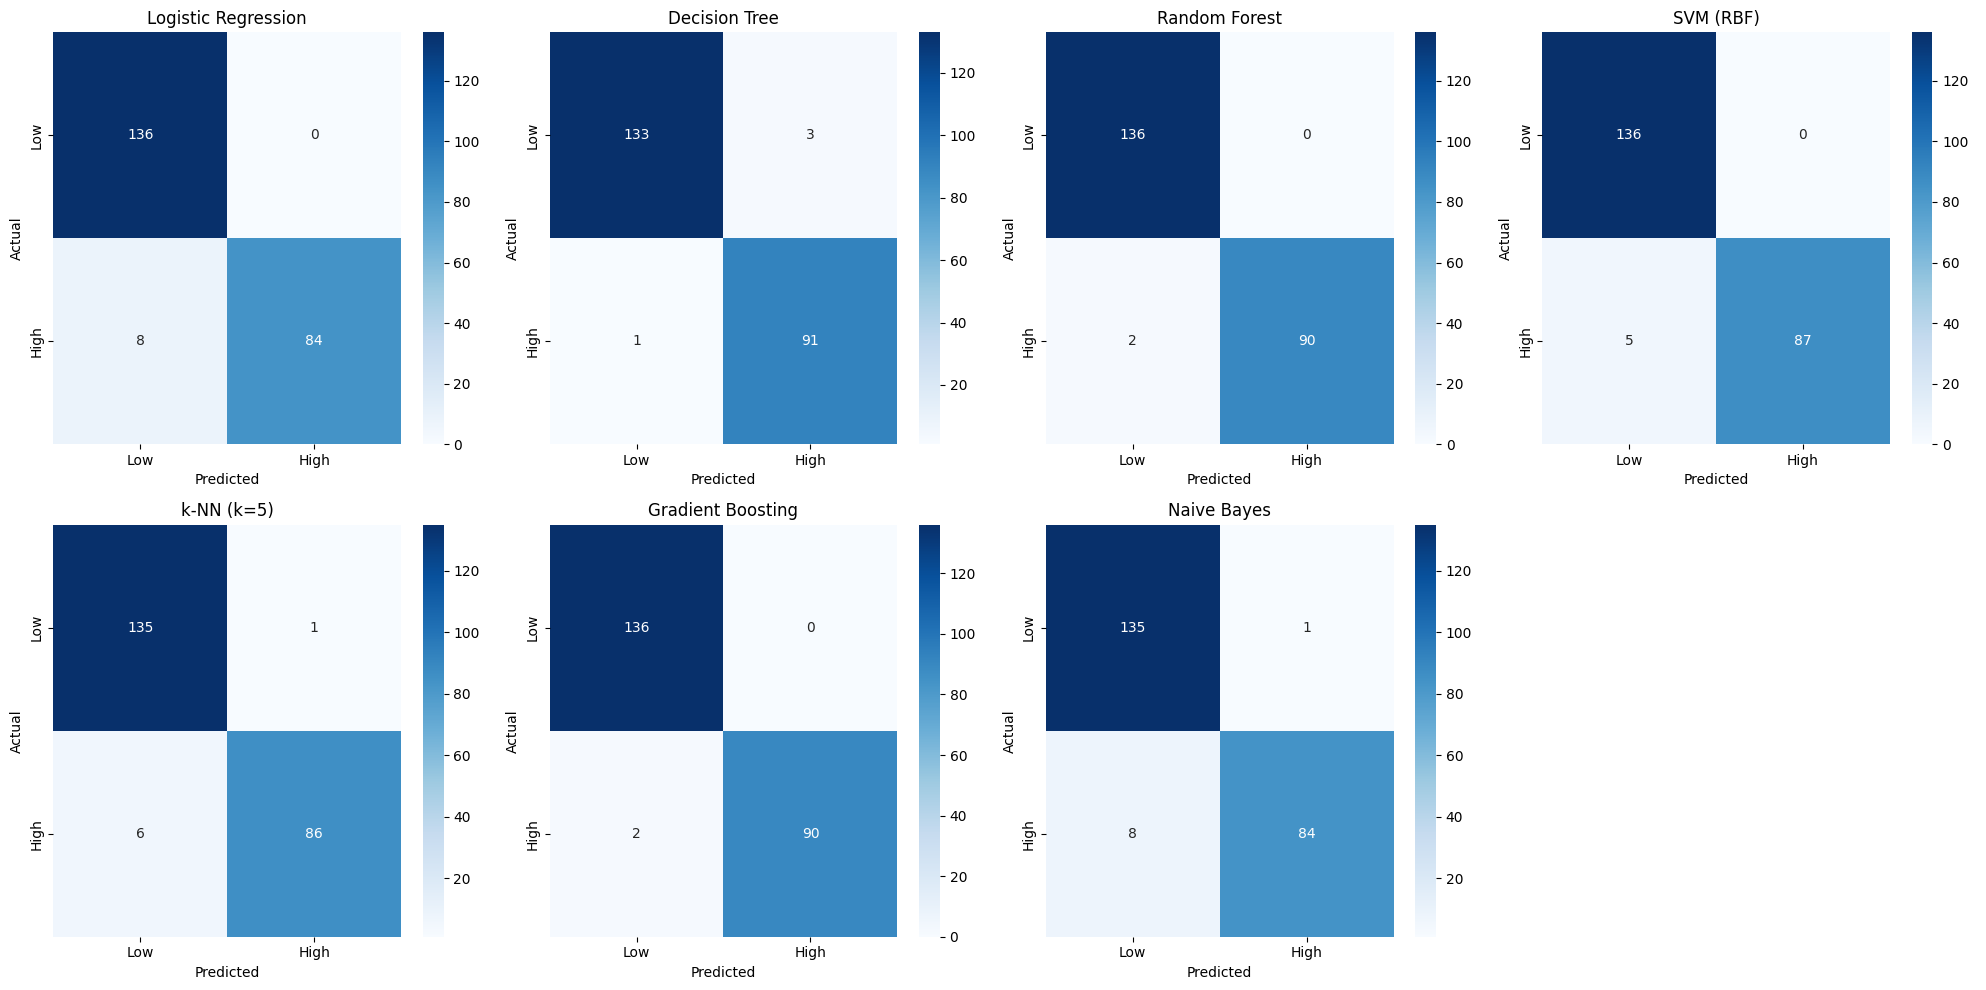


--- Numeričke vrijednosti konfuzijskih matrica ---

Logistic Regression:
  True Negatives (Low correctly predicted): 136
  False Positives (Low predicted as High): 0
  False Negatives (High predicted as Low): 8
  True Positives (High correctly predicted): 84

Decision Tree:
  True Negatives (Low correctly predicted): 133
  False Positives (Low predicted as High): 3
  False Negatives (High predicted as Low): 1
  True Positives (High correctly predicted): 91

Random Forest:
  True Negatives (Low correctly predicted): 136
  False Positives (Low predicted as High): 0
  False Negatives (High predicted as Low): 2
  True Positives (High correctly predicted): 90

SVM (RBF):
  True Negatives (Low correctly predicted): 136
  False Positives (Low predicted as High): 0
  False Negatives (High predicted as Low): 5
  True Positives (High correctly predicted): 87

k-NN (k=5):
  True Negatives (Low correctly predicted): 135
  False Positives (Low predicted as High): 1
  False Negatives (High predicte

In [90]:
# Use Pipelines for SVM and k-NN to ensure proper scaling without data leakage
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": Pipeline([('scaler', StandardScaler()), ('svm', SVC(probability=True, random_state=42))]),
    "k-NN (k=5)": Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))]),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB()
}

data_for_model = {
    "Logistic Regression": (x_train, x_test),
    "Decision Tree": (x_train, x_test),
    "Random Forest": (x_train, x_test),
    "SVM (RBF)": (x_train, x_test),  # Pipeline handles scaling internally
    "k-NN (k=5)": (x_train, x_test),  # Pipeline handles scaling internally
    "Gradient Boosting": (x_train, x_test),
    "Naive Bayes": (x_train, x_test)
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    X_tr, X_te = data_for_model[name]
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

for j in range(len(models), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


print("\n--- Numeričke vrijednosti konfuzijskih matrica ---")
for name, model in models.items():
    X_tr, X_te = data_for_model[name]
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"\n{name}:")
    print(f"  True Negatives (Low correctly predicted): {tn}")
    print(f"  False Positives (Low predicted as High): {fp}")
    print(f"  False Negatives (High predicted as Low): {fn}")
    print(f"  True Positives (High correctly predicted): {tp}")

Decision Tree is prone to overfitting and is less stable on new data, while Gradient Boosting and Random Forest are more robust and provide a better balance across the entire test set.

Decision Tree je sklon overfittingu i manje je stabilan na novim podacima, dok su Gradient Boosting i Random Forest robusniji i daju bolji balans na cijelom testnom skupu.

## 5‑fold cross‑validation is crucial for assessing model stability and generalization, especially in medical applications.
If a model performs excellently on the training set but poorly on cross‑validation, that is a sign of overfitting.
Small standard deviations (±0.008) mean that the model is stable – it behaves consistently across different data subsets, which is crucial for medical applications.
5-fold križna validacija je ključna za procjenu stabilnosti i generalizacije modela, posebno u medicinskim primjenama.
Ako model ima odlične rezultate na trening skupu, ali loše na križnoj validaciji, to je znak overfittinga.
Male standardne devijacije (±0.008) znače da je model stabilan – ponaša se dosljedno na različitim podskupovima podataka, što je ključno za medicinsku primjenu.

In [91]:
all_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM (RBF)": Pipeline([('scaler', StandardScaler()), ('svm', SVC(probability=True, random_state=42))]),
    "k-NN (k=5)": Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))]),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
}


scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in all_models.items():
    scores = cross_validate(model, x, y, cv=cv, scoring=scoring, 
                            return_train_score=False, n_jobs=-1)
    mean_scores = {f'mean_{m}': np.mean(scores[f'test_{m}']) for m in scoring}
    std_scores = {f'std_{m}': np.std(scores[f'test_{m}']) for m in scoring}
    results.append({
        'Model': name,
        **mean_scores,
        **std_scores
    })

results_df = pd.DataFrame(results)
results_df = results_df.round(4)

results_df = results_df.sort_values('mean_f1', ascending=False)

print("=== REZULTATI 5-FOLD KRIŽNE VALIDACIJE ===\n")
print(results_df[['Model', 'mean_accuracy', 'mean_precision', 'mean_recall', 'mean_f1', 'mean_roc_auc']])

best_model = results_df.iloc[0]
print(f"\n📌 Najbolji model po F1 score: {best_model['Model']}")
print(f"   F1 = {best_model['mean_f1']:.4f} ± {best_model['std_f1']:.4f}")
print(f"   Recall = {best_model['mean_recall']:.4f} ± {best_model['std_recall']:.4f}")
print(f"   AUC = {best_model['mean_roc_auc']:.4f} ± {best_model['std_roc_auc']:.4f}")

=== REZULTATI 5-FOLD KRIŽNE VALIDACIJE ===

                 Model  mean_accuracy  mean_precision  mean_recall  mean_f1  \
3    Gradient Boosting         0.9877          0.9849       0.9848   0.9848   
7              XGBoost         0.9868          0.9808       0.9870   0.9838   
2        Random Forest         0.9789          0.9644       0.9848   0.9744   
6           k-NN (k=5)         0.9737          0.9633       0.9717   0.9675   
5            SVM (RBF)         0.9711          0.9553       0.9739   0.9645   
1        Decision Tree         0.9675          0.9490       0.9717   0.9601   
0  Logistic Regression         0.9614          0.9542       0.9500   0.9519   
4          Naive Bayes         0.9596          0.9561       0.9435   0.9496   

   mean_roc_auc  
3        0.9992  
7        0.9991  
2        0.9988  
6        0.9901  
5        0.9977  
1        0.9682  
0        0.9951  
4        0.9902  

📌 Najbolji model po F1 score: Gradient Boosting
   F1 = 0.9848 ± 0.0134
   Recall

## Gradient Boosting Feature Importance - Važnost značajki u Gradient Boosting modelu

Feature importance reveals which variables contribute most to the model's predictions, which is crucial in medical applications to understand the risk factors driving the classification.

GRADIENT BOOSTING — VAŽNOST ZNAČAJKI (Feature Importance)

Značajke sortirane po važnosti:

dijabetes                      0.2556
glukoza_u_krvi                 0.1892
BMI                            0.1803
gestacijski_dijabetes          0.1755
otkucaji_srca                  0.0911
mentalno_zdravlje              0.0785
komplikacije_u_proslosti       0.0201
dob                            0.0049
sistolicki_krvni_tlak          0.0038
dijastolicki_krvni_tlak        0.0008
tjelesna_temp                  0.0003


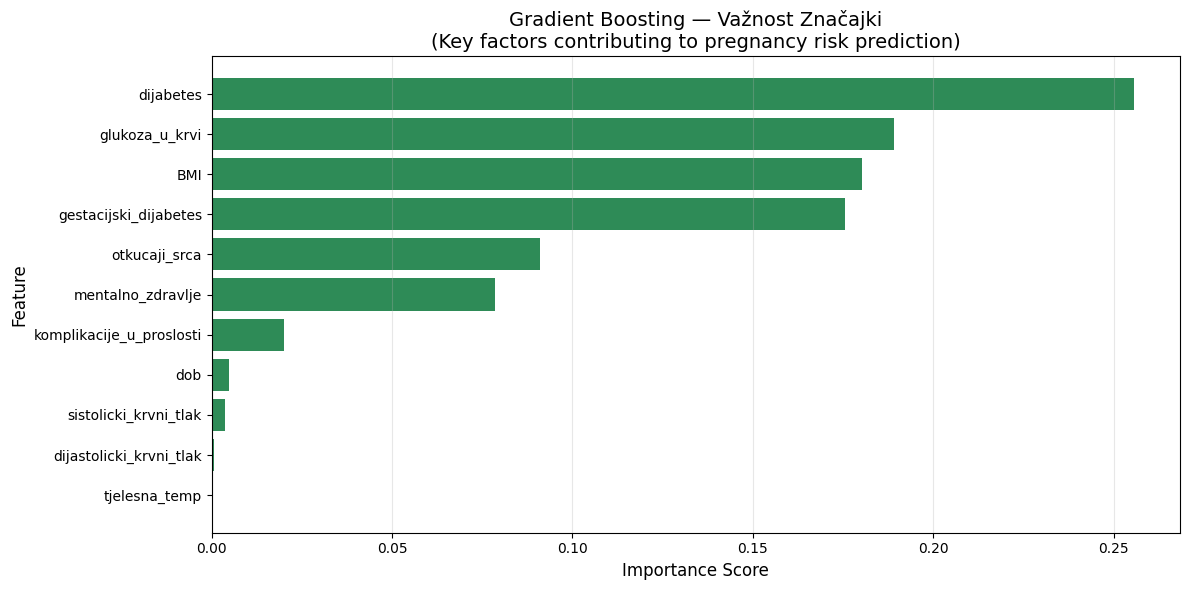

In [92]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(x, y)

feature_importance_gb = pd.DataFrame({
    'Feature': x.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("=" * 60)
print("GRADIENT BOOSTING — VAŽNOST ZNAČAJKI (Feature Importance)")
print("=" * 60)
print("\nZnačajke sortirane po važnosti:\n")
for idx, row in feature_importance_gb.iterrows():
    print(f"{row['Feature']:30s} {row['Importance']:.4f}")

plt.figure(figsize=(12, 6))
plt.barh(feature_importance_gb['Feature'], feature_importance_gb['Importance'], color='seagreen')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Gradient Boosting — Važnost Značajki\n(Key factors contributing to pregnancy risk prediction)', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion - zakljucak
The Gradient Boosting model achieves near-perfect performance (F1 ≈ 0.985, AUC ≈ 0.999), with diabetes, blood glucose, and BMI being the most important predictors.
Model Gradient Boosting postiže gotovo savršene performanse (F1 ≈ 0,985, AUC ≈ 0,999), a najvažnije značajke su dijabetes, glukoza u krvi i BMI.